# Compare all EngressNet batches

Loads `metrics.csv` from every `results/<batch>/<run>/` folder (the prior
FOSI experiment lineage, e.g. `FOSI_land_fix4`, `FOSI_tile_fix`, `FOSI_2conv`,
plus the new sensitivity-test batches from `submit_sensitivity_tests.sh`) and
compares them in heatmaps: batch vs. metric, and batch vs. train/test split.

Reads only `metrics.csv` (+ `run_config.json` where present) -- no GPU, no
`xesmf`/`pop_tools`, no `eval_data/` needed, so this runs fast and needs only
`pandas`/`numpy`/`matplotlib` from `downscaling_env`.

In [2]:
import glob
import json
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_DIR = "/glade/work/skygale/_projects/SeaIceDownscaling/Version4/results"

# Batches to skip entirely -- different underlying dataset/pipeline
# (MESACLIP CESM-LE perfect-model runs, not the FOSI_BGC HR record the rest
# of this comparison uses), not an apples-to-apples comparison.
EXCLUDE_BATCHES = {"MESA_old"}

# Preferred left-to-right/top-to-bottom order: the FOSI experiment lineage in
# chronological order, then the sensitivity-test batches grouped by which of
# the 5 tests they belong to. Any batch found on disk but not listed here
# (e.g. a new one) is appended at the end, alphabetically, rather than
# silently dropped.
PREFERRED_ORDER = [
    "FOSI_old", "FOSI_bad_coastal", "FOSI_new_coastal",
    "FOSI_land_fix", "FOSI_land_fix2", "FOSI_land_fix3", "FOSI_land_fix4",
    "FOSI_tile_fix", "FOSI_expdom_20k", "FOSI_2conv",
    "FOSI_epochs40",
    "FOSI_beta0.5", "FOSI_beta0.75", "FOSI_beta1.5",
    "FOSI_extralayer1024", "FOSI_enscale_lite",
    "FOSI_domain_tiny", "FOSI_domain_large",
]

# The batch every sensitivity test is a single-axis change relative to (see
# submit_sensitivity_tests.sh) -- used for the "vs. baseline" heatmap below.
BASELINE_BATCH = "FOSI_2conv"

In [3]:
def parse_split_label(run_dirname):
    '''Pull the (train, test) year-range labels out of a run directory name.
    Handles both naming conventions seen on disk:
        FOSI_nopatches_1960-1970_2010-2020_5280654.casper-pbs
        FOSI_nopatches_train1958-2000_test2001-2022_5206874
    '''
    years = re.findall(r"\d{4}-\d{4}", run_dirname)
    if len(years) >= 2:
        return years[0], years[1]
    return "unknown", "unknown"


def load_all_metrics(results_dir):
    rows = []
    for metrics_path in sorted(glob.glob(os.path.join(results_dir, "*", "*", "metrics.csv"))):
        run_dir = os.path.dirname(metrics_path)
        batch = os.path.basename(os.path.dirname(run_dir))
        run_name = os.path.basename(run_dir)
        if batch in EXCLUDE_BATCHES:
            continue

        train_label, test_label = parse_split_label(run_name)
        df = pd.read_csv(metrics_path)
        df["batch"] = batch
        df["run"] = run_name
        df["train_years"] = train_label
        df["test_years"] = test_label
        df["split"] = f"{train_label} -> {test_label}"
        rows.append(df)

    if not rows:
        raise RuntimeError(f"No metrics.csv found under {results_dir}/*/*/metrics.csv")
    return pd.concat(rows, ignore_index=True)


metrics_long = load_all_metrics(RESULTS_DIR)
print(f"Loaded {len(metrics_long)} metric rows from "
      f"{metrics_long['batch'].nunique()} batches, "
      f"{metrics_long.groupby('batch')['run'].nunique().sum()} runs total.")
metrics_long.groupby("batch")["run"].nunique().rename("n_runs")

Loaded 267 metric rows from 18 batches, 89 runs total.


batch
FOSI_2conv             5
FOSI_bad_coastal       5
FOSI_beta0.5           5
FOSI_beta0.75          5
FOSI_beta1.5           5
FOSI_domain_large      5
FOSI_domain_tiny       5
FOSI_enscale_lite      5
FOSI_epochs40          5
FOSI_expdom_20k        5
FOSI_extralayer1024    5
FOSI_land_fix          5
FOSI_land_fix2         5
FOSI_land_fix3         5
FOSI_land_fix4         5
FOSI_new_coastal       5
FOSI_old               4
FOSI_tile_fix          5
Name: n_runs, dtype: int64

In [4]:
def ordered_batches(present):
    ordered = [b for b in PREFERRED_ORDER if b in present]
    extra = sorted(set(present) - set(ordered))
    return ordered + extra


BATCHES = ordered_batches(set(metrics_long["batch"].unique()))
print(f"{len(BATCHES)} batches, in comparison order:")
for b in BATCHES:
    print(" ", b)

18 batches, in comparison order:
  FOSI_old
  FOSI_bad_coastal
  FOSI_new_coastal
  FOSI_land_fix
  FOSI_land_fix2
  FOSI_land_fix3
  FOSI_land_fix4
  FOSI_tile_fix
  FOSI_expdom_20k
  FOSI_2conv
  FOSI_epochs40
  FOSI_beta0.5
  FOSI_beta0.75
  FOSI_beta1.5
  FOSI_extralayer1024
  FOSI_enscale_lite
  FOSI_domain_tiny
  FOSI_domain_large


## Heatmap 1: batch x metric overview (Stochastic UNet Mean)

Every metric has a different unit and a different "good" direction (lower is
better for MAE/RMSE/Grad MAE/IIEE/Coastal MAE/Coastal RMSE; higher is better
for Pattern Corr/SSIM; closer to 0 is better for Bias; closer to 1 is better
for Spread/Error, since that's the ideal ensemble-calibration value). Each
column is independently rescaled to a single "how good is this batch on this
metric, relative to every other batch" score in [0, 1] (0 = best, 1 = worst)
so the whole table can share one sequential color ramp -- the annotated
number in each cell is always the real metric value, only the cell shading is
normalized.

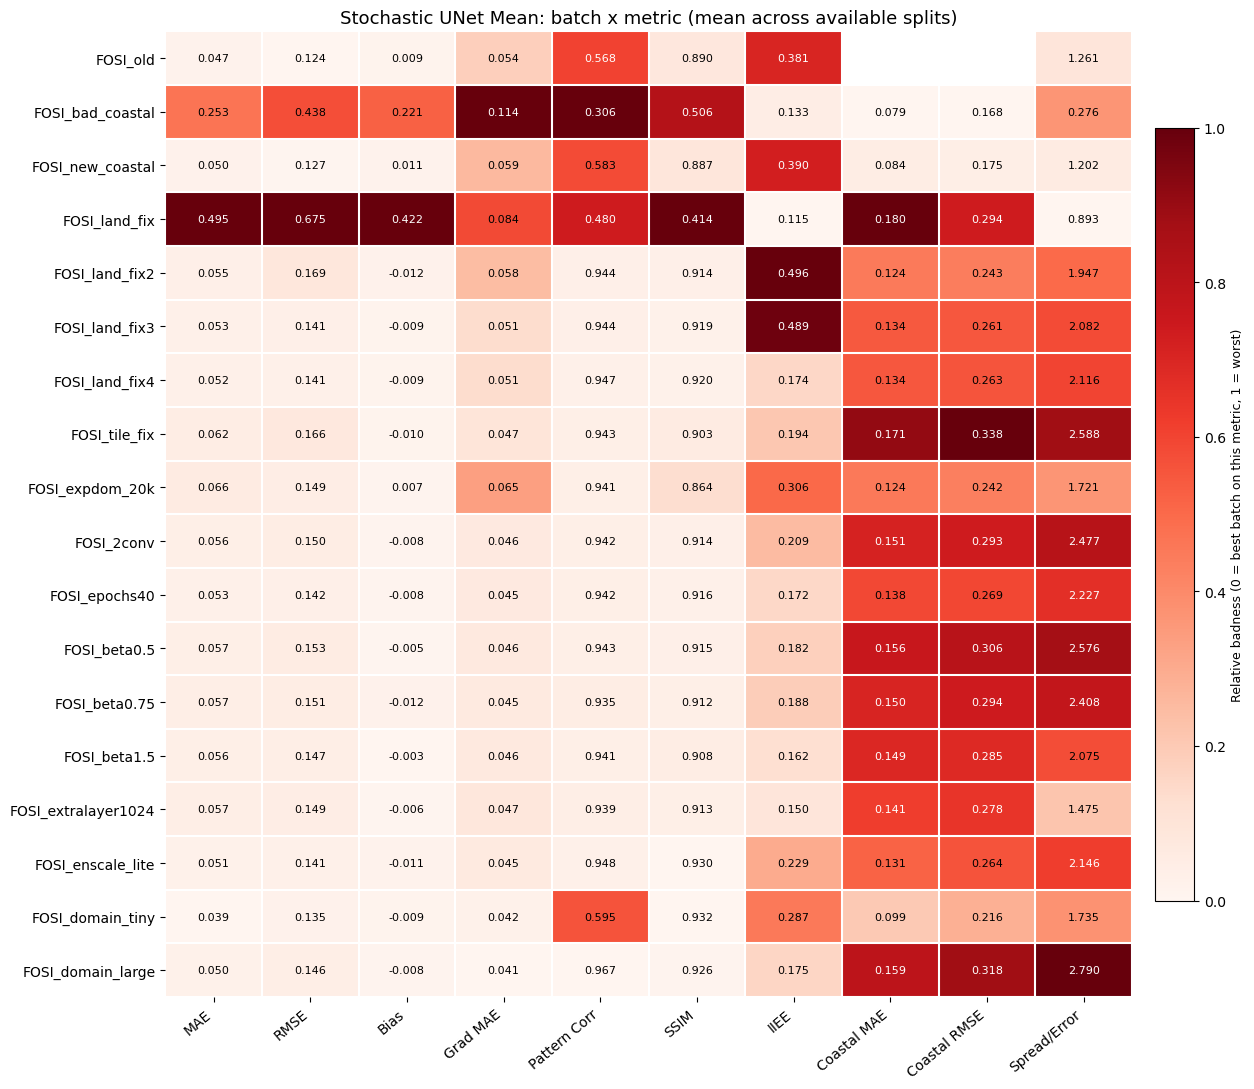

In [5]:
METRIC_DIRECTION = {
    "MAE": "lower", "RMSE": "lower", "Bias": "zero", "Grad MAE": "lower",
    "Pattern Corr": "higher", "SSIM": "higher", "IIEE": "lower",
    "Coastal MAE": "lower", "Coastal RMSE": "lower", "Spread/Error": "one",
}
METRIC_COLS = list(METRIC_DIRECTION.keys())


def badness(series, direction):
    if direction == "lower":
        return series
    if direction == "higher":
        return -series
    if direction == "zero":
        return series.abs()
    if direction == "one":
        return (series - 1).abs()
    raise ValueError(direction)


def normalize_0_1(series):
    lo, hi = series.min(), series.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi - lo < 1e-12:
        return series * 0.0  # constant (or all-NaN) column -> neutral color
    return (series - lo) / (hi - lo)


def plot_badness_heatmap(value_df, title, figsize=None, cmap="Reds", fmt="{:.3f}"):
    '''value_df: batches (rows) x metrics (cols) raw values. Colors are the
    per-column badness-normalized score; annotations are the raw values.'''
    badness_df = pd.DataFrame(index=value_df.index, columns=value_df.columns, dtype=float)
    for col in value_df.columns:
        direction = METRIC_DIRECTION.get(col, "lower")
        badness_df[col] = normalize_0_1(badness(value_df[col], direction))

    if figsize is None:
        figsize = (1.15 * len(value_df.columns) + 2, 0.5 * len(value_df.index) + 2)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(badness_df.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(value_df.columns)))
    ax.set_xticklabels(value_df.columns, rotation=40, ha="right")
    ax.set_yticks(range(len(value_df.index)))
    ax.set_yticklabels(value_df.index)

    for i in range(value_df.shape[0]):
        for j in range(value_df.shape[1]):
            v = value_df.values[i, j]
            if pd.isna(v):
                continue
            b = badness_df.values[i, j]
            text_color = "white" if b > 0.6 else "black"
            ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=8, color=text_color)

    ax.set_title(title, fontsize=13)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks(np.arange(-0.5, len(value_df.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(value_df.index), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label("Relative badness (0 = best batch on this metric, 1 = worst)", fontsize=9)
    fig.tight_layout()
    return fig, ax


stoch_mean = metrics_long[metrics_long["Method"] == "Stochastic UNet Mean"]
batch_metric = (
    stoch_mean.groupby("batch")[METRIC_COLS].mean()
    .reindex(BATCHES)
)

fig, ax = plot_badness_heatmap(
    batch_metric, "Stochastic UNet Mean: batch x metric (mean across available splits)",
)
plt.show()

## Heatmap 2: RMSE, per batch per split

Same "Stochastic UNet Mean" method, but broken out by individual train/test
split instead of averaged, so per-split variability within a batch (and
missing splits, shown blank) is visible directly.

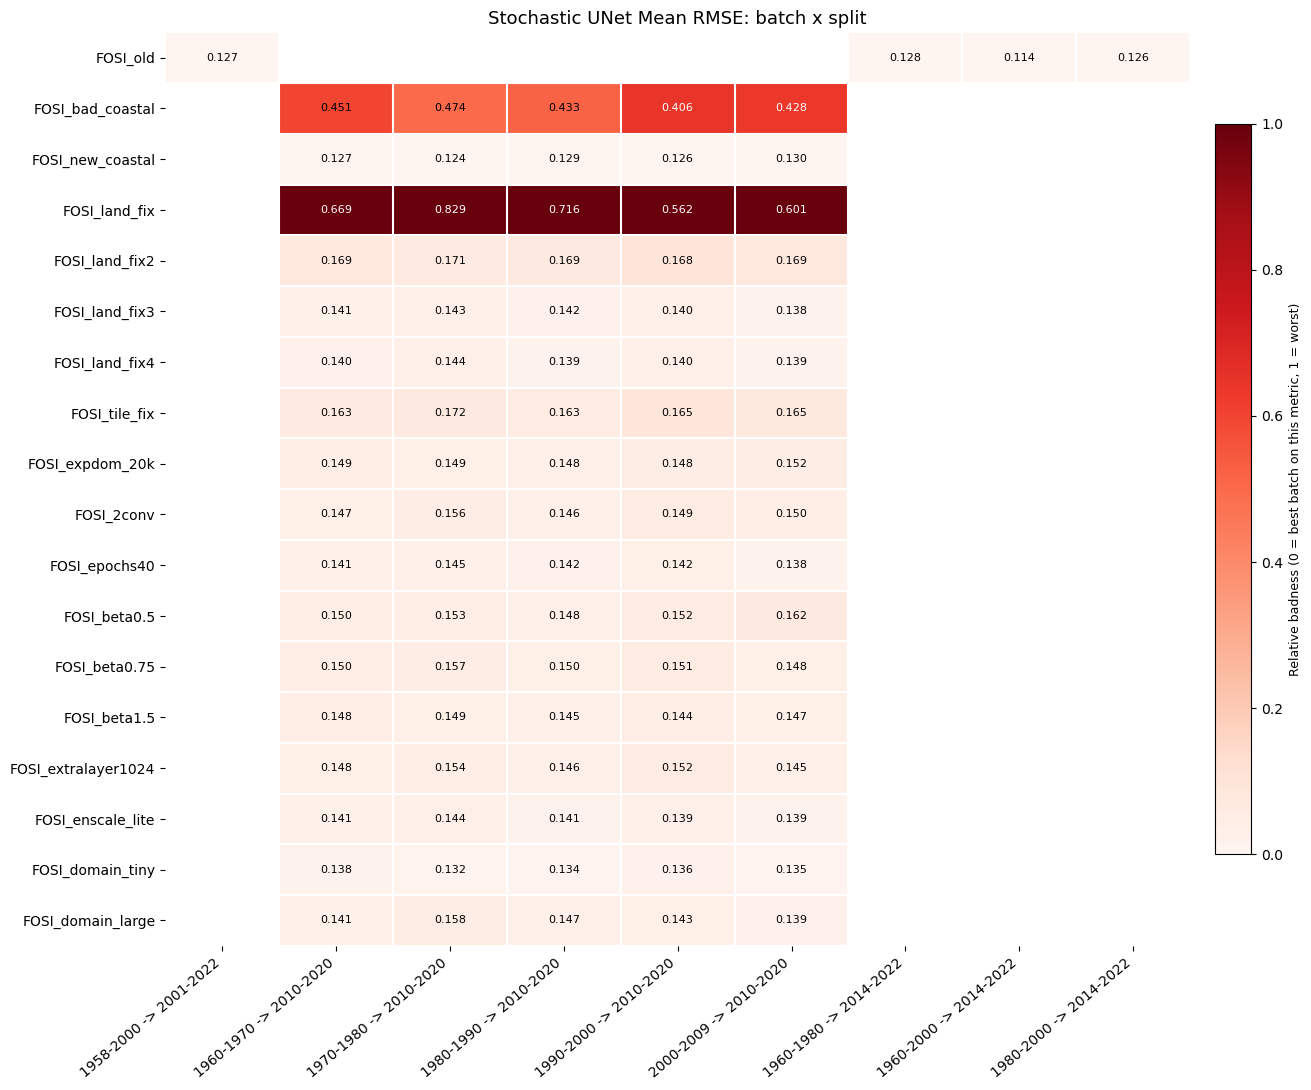

In [6]:
def split_pivot(metric, method="Stochastic UNet Mean"):
    sub = metrics_long[metrics_long["Method"] == method]
    pivot = sub.pivot_table(index="batch", columns="split", values=metric, aggfunc="mean")
    return pivot.reindex(BATCHES)


rmse_pivot = split_pivot("RMSE")
# Order split columns by test-then-train year so the standard 5-way sweep
# (all sharing test_years=2010-2020) reads left-to-right by training period.
split_order = sorted(rmse_pivot.columns, key=lambda s: (s.split(' -> ')[1], s.split(' -> ')[0]))
rmse_pivot = rmse_pivot[split_order]

fig, ax = plot_badness_heatmap(
    rmse_pivot, "Stochastic UNet Mean RMSE: batch x split",
    figsize=(1.3 * len(rmse_pivot.columns) + 2.5, 0.5 * len(rmse_pivot.index) + 2),
)
plt.show()

## Heatmap 3: Spread/Error, per batch per split

Spread/Error is a ratio, not an error -- 1.0 is the calibration target (ensemble
spread matches actual error), <1 is under-dispersed, >1 is over-dispersed. This
is the metric at the center of the open "Spread/Error stayed elevated" thread
from the `FOSI_2conv` batch, so it gets its own diverging-around-1 color scale
(blue = under-dispersed, white = ~1.0/well-calibrated, red = over-dispersed)
instead of the sequential "badness" ramp used above.

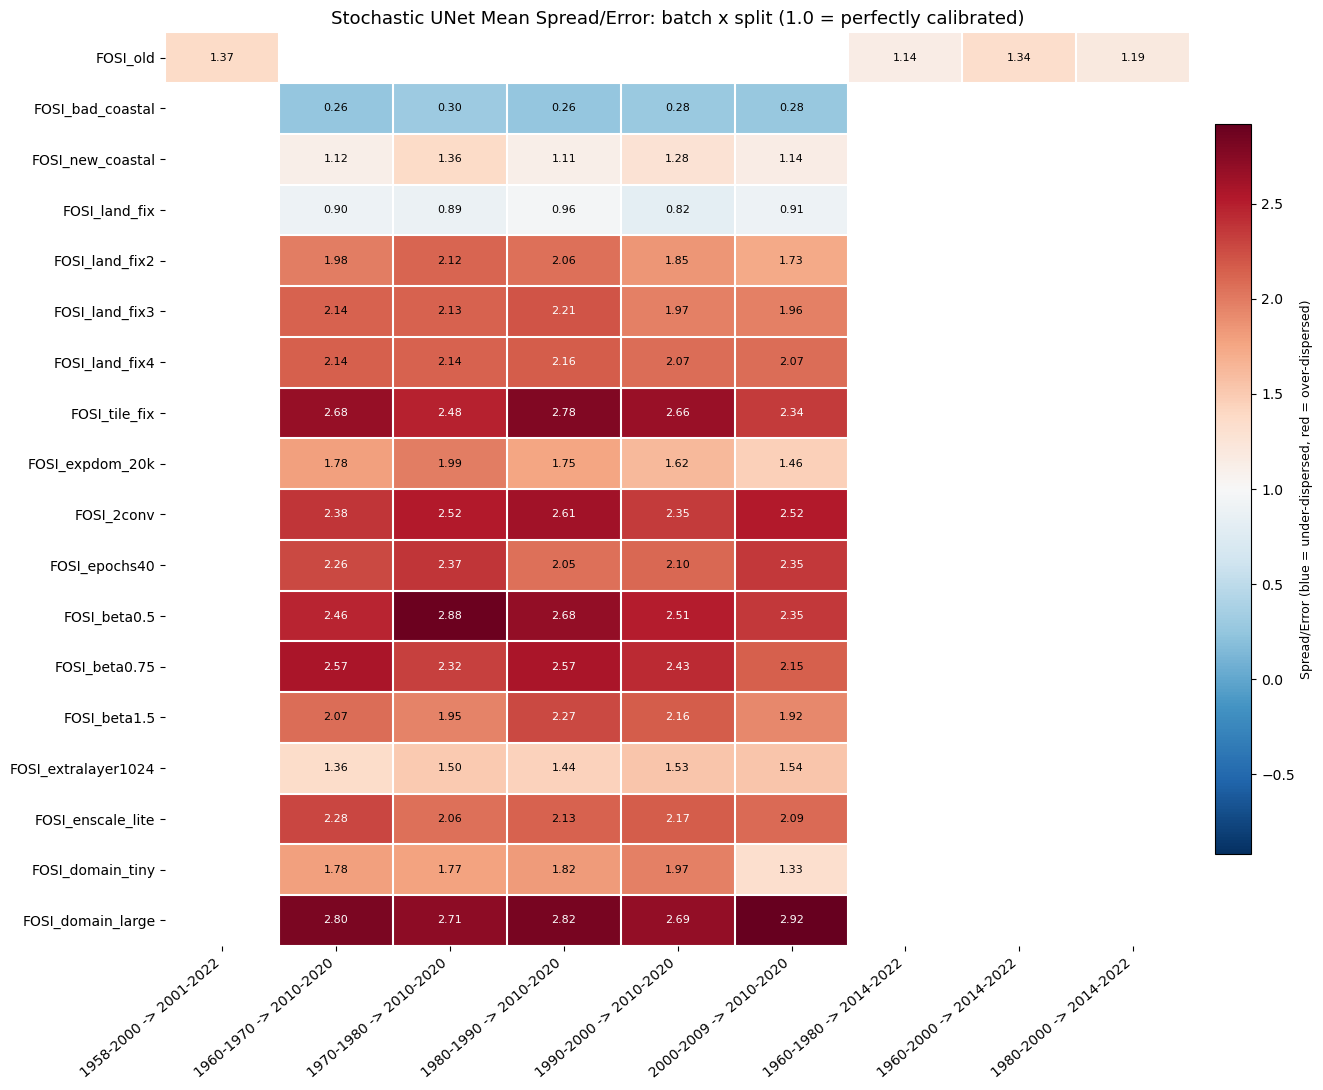

In [7]:
from matplotlib.colors import TwoSlopeNorm

spread_pivot = split_pivot("Spread/Error")[split_order]

fig, ax = plt.subplots(figsize=(1.3 * len(spread_pivot.columns) + 2.5, 0.5 * len(spread_pivot.index) + 2))
finite_vals = spread_pivot.values[np.isfinite(spread_pivot.values)]
vmax_dev = max(0.05, np.nanmax(np.abs(finite_vals - 1)) if finite_vals.size else 0.05)
norm = TwoSlopeNorm(vmin=1 - vmax_dev, vcenter=1.0, vmax=1 + vmax_dev)
im = ax.imshow(spread_pivot.values, cmap="RdBu_r", norm=norm, aspect="auto")

ax.set_xticks(range(len(spread_pivot.columns)))
ax.set_xticklabels(spread_pivot.columns, rotation=40, ha="right")
ax.set_yticks(range(len(spread_pivot.index)))
ax.set_yticklabels(spread_pivot.index)
for i in range(spread_pivot.shape[0]):
    for j in range(spread_pivot.shape[1]):
        v = spread_pivot.values[i, j]
        if pd.isna(v):
            continue
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v - 1) > 0.6 * vmax_dev else "black")
ax.set_title("Stochastic UNet Mean Spread/Error: batch x split (1.0 = perfectly calibrated)", fontsize=13)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(spread_pivot.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(spread_pivot.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Spread/Error (blue = under-dispersed, red = over-dispersed)", fontsize=9)
fig.tight_layout()
plt.show()

## Heatmap 4: sensitivity batches vs. the `FOSI_2conv` baseline

Every sensitivity-test batch (`FOSI_epochs40`, `FOSI_beta*`, `FOSI_extralayer1024`,
`FOSI_enscale_lite`, `FOSI_domain_tiny/large`) changes exactly one thing relative
to `FOSI_2conv` (see `submit_sensitivity_tests.sh`). This shows percent change per
metric, **sign-flipped so positive (green) always means "improvement"** regardless
of whether the metric's own good direction is up or down -- e.g. a drop in RMSE
and a rise in Pattern Corr both show as green. Bias and Spread/Error are shown as
the change in *distance from their ideal value* (0 and 1 respectively), for the
same reason.

Percent change vs. a near-zero baseline (Bias in particular -- `FOSI_2conv`'s
baseline bias is only -0.008) blows up into huge, meaningless swings that would
otherwise saturate the color scale and wash out every other, real, difference.
So **each metric column is colored on its own independent green<->red scale**
(the worst mover in that column is fully saturated; every other column keeps
its own full range) -- only the annotated numbers are the true percent changes,
same principle as the per-column normalization in Heatmap 1.

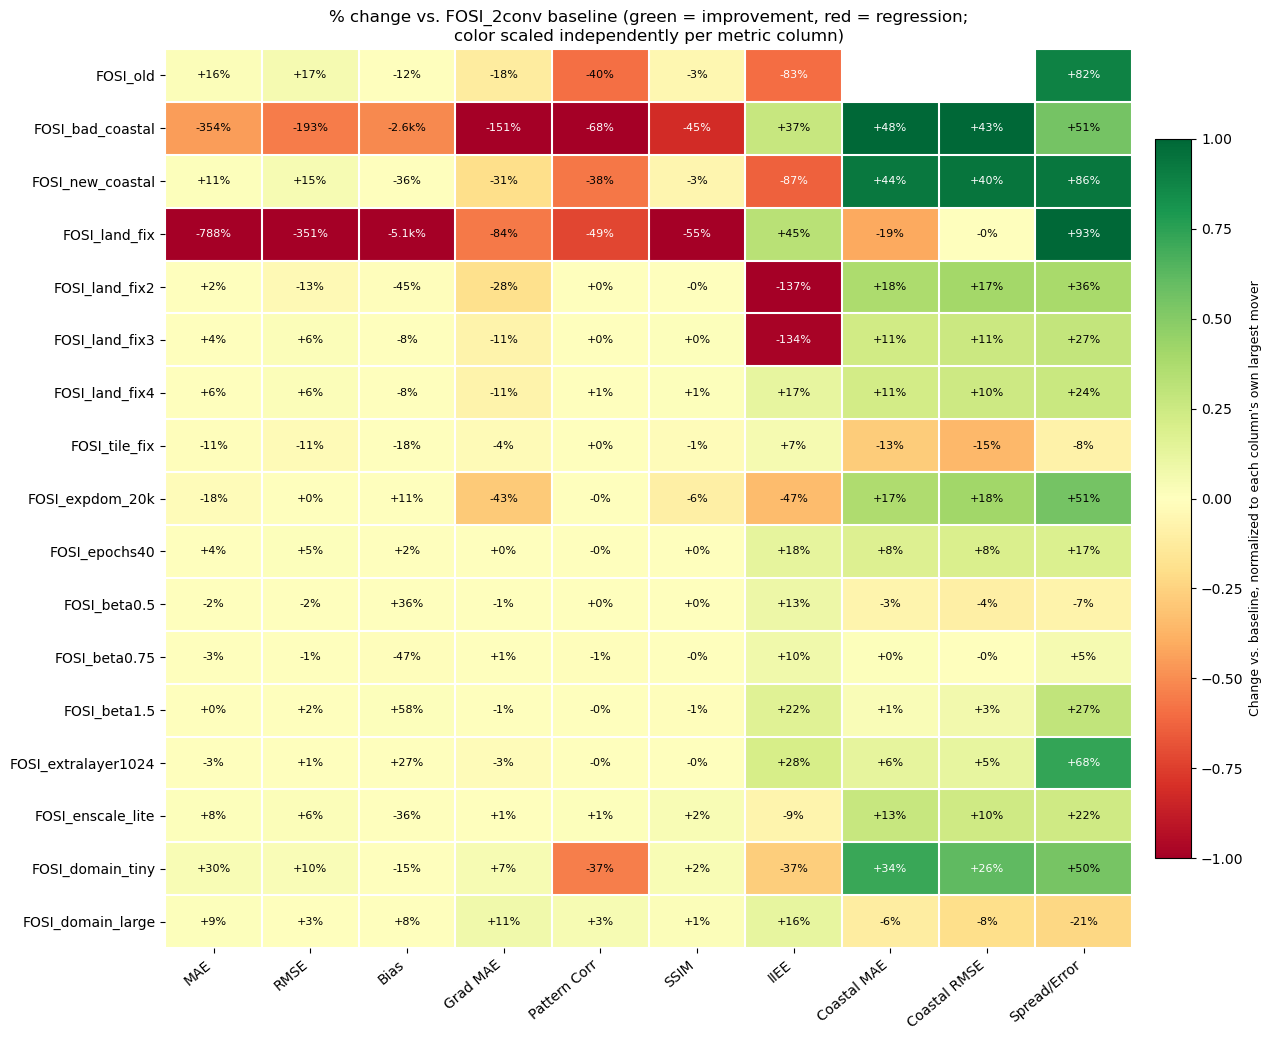

In [8]:
baseline_row = batch_metric.loc[BASELINE_BATCH]
test_batches = [b for b in BATCHES if b != BASELINE_BATCH]

pct_change = pd.DataFrame(index=test_batches, columns=METRIC_COLS, dtype=float)
for col in METRIC_COLS:
    direction = METRIC_DIRECTION[col]
    base_val = baseline_row[col]
    for b in test_batches:
        val = batch_metric.loc[b, col]
        if pd.isna(val) or pd.isna(base_val):
            continue
        base_badness, val_badness = badness(pd.Series([base_val, val]), direction)
        # % change in badness, sign-flipped so improvement (badness decreases) -> positive
        if abs(base_badness) < 1e-9:
            pct_change.loc[b, col] = np.nan
        else:
            pct_change.loc[b, col] = -100 * (val_badness - base_badness) / abs(base_badness)

# Per-column color normalization (see markdown above): each metric's own worst
# mover saturates that column's color scale, independent of every other column,
# so one metric's near-zero-baseline blowup can't wash out the rest.
color_scale = pd.DataFrame(index=pct_change.index, columns=pct_change.columns, dtype=float)
for col in pct_change.columns:
    col_vals = pct_change[col]
    col_max = np.nanmax(np.abs(col_vals.values)) if np.isfinite(col_vals.values).any() else 1.0
    col_max = max(col_max, 1e-9)
    color_scale[col] = (col_vals / col_max).clip(-1, 1)

fig, ax = plt.subplots(figsize=(1.15 * len(METRIC_COLS) + 2, 0.5 * len(test_batches) + 2))
im = ax.imshow(color_scale.values.astype(float), cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(METRIC_COLS)))
ax.set_xticklabels(METRIC_COLS, rotation=40, ha="right")
ax.set_yticks(range(len(test_batches)))
ax.set_yticklabels(test_batches)
for i in range(pct_change.shape[0]):
    for j in range(pct_change.shape[1]):
        v = pct_change.values[i, j]
        if pd.isna(v):
            continue
        c = color_scale.values[i, j]
        label = f"{v:+.0f}%" if abs(v) < 1000 else (f"+{v/1000:.1f}k%" if v > 0 else f"{v/1000:.1f}k%")
        ax.text(j, i, label, ha="center", va="center", fontsize=8,
                color="white" if abs(c) > 0.6 else "black")
ax.set_title(f"% change vs. {BASELINE_BATCH} baseline (green = improvement, red = regression;\ncolor scaled independently per metric column)", fontsize=12)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks(np.arange(-0.5, len(METRIC_COLS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(test_batches), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", bottom=False, left=False)
cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Change vs. baseline, normalized to each column's own largest mover", fontsize=9)
fig.tight_layout()
plt.show()

## Appendix: per-batch config summary (where recorded)

Best-effort table of the hyperparameters that actually differ between batches,
read from each batch's first run's `run_config.json` (only present for runs
made after `save_run_config()` was added -- see `description.txt` inside older
run folders for a best-effort reconstruction otherwise).

In [9]:
CONFIG_FIELDS = [
    "num_epochs", "k", "k_eval", "beta", "extra_layer", "stochastic_refine",
    "coastal_width", "coastal_boost", "land_threshold", "subdomain",
]

config_rows = []
for batch in BATCHES:
    run_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, batch, "*")))
    row = {"batch": batch}
    if run_dirs:
        cfg_path = os.path.join(run_dirs[0], "run_config.json")
        if os.path.exists(cfg_path):
            with open(cfg_path) as f:
                cfg = json.load(f)
            for field in CONFIG_FIELDS:
                row[field] = cfg.get(field, None)
        else:
            row["num_epochs"] = "predates run_config.json"
    config_rows.append(row)

pd.DataFrame(config_rows).set_index("batch")

,num_epochs,k,k_eval,beta,extra_layer,stochastic_refine,coastal_width,coastal_boost,land_threshold,subdomain
batch,,,,,,,,,,
FOSI_old,predates run_config.json,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FOSI_bad_coastal,20,9.0,6.0,1.00,None,None,5.0,2.0,NaN,"{'lat_min': 62.0, 'lat_max': 69.0, 'lon_min': ..."
FOSI_new_coastal,20,9.0,6.0,1.00,None,None,5.0,2.0,NaN,"{'lat_min': 62.0, 'lat_max': 69.0, 'lon_min': ..."
FOSI_land_fix,20,20.0,20.0,0.80,None,None,5.0,2.0,NaN,"{'lat_min': 60.0, 'lat_max': 75.0, 'lon_min': ..."
FOSI_land_fix2,20,20.0,20.0,0.80,None,None,5.0,2.0,NaN,"{'lat_min': 60.0, 'lat_max': 75.0, 'lon_min': ..."
FOSI_land_fix3,20,20.0,20.0,0.80,None,None,5.0,2.0,0.1,"{'lat_min': 60.0, 'lat_max': 75.0, 'lon_min': ..."
FOSI_land_fix4,20,20.0,20.0,0.80,None,None,5.0,2.0,0.1,"{'lat_min': 60.0, 'lat_max': 75.0, 'lon_min': ..."
FOSI_tile_fix,20,20.0,20.0,0.80,None,None,5.0,2.0,0.1,"{'lat_min': 60.0, 'lat_max': 75.0, 'lon_min': ..."
FOSI_expdom_20k,20,20.0,20.0,0.80,None,None,5.0,2.0,NaN,"{'lat_min': 60.0, 'lat_max': 75.0, 'lon_min': ..."
